80-10-10

--- BƯỚC 1: UPLOAD FILE ---
1. Upload file Ngân hàng:


Saving BAC.csv to BAC.csv
Saving JPM.csv to JPM.csv
Saving WFC.csv to WFC.csv
2. Upload file S&P 500:


Saving SPX500.csv to SPX500.csv
3. Upload file FED:


Saving FED_RATE.csv to FED_RATE.csv
4. Upload file Sentiment:


Saving Dữ liệu hành vi.csv to Dữ liệu hành vi.csv
   > Tìm thấy cột ngày: 'Date'. Đang chuẩn hóa...
   > Tìm thấy cột ngày: 'Date'. Đang chuẩn hóa...
   > Tìm thấy cột ngày: 'date'. Đang chuẩn hóa...

Xử lý xong dữ liệu ngoại sinh.

ĐANG XỬ LÝ: BAC.csv (LSTM - 80/10/10)
   > Tìm thấy cột ngày: 'Date'. Đang chuẩn hóa...
   > Biến ngoại sinh: ['SPX500_Close', 'EFFR', 'BAC_news_count', 'BAC_avg_sentiment']
   > Train: 1581, Val: 198, Test: 198
   > Đang chuẩn hóa dữ liệu (Scaling)...
   > Tạo cửa sổ (TimeSteps=22)...
   > Xây dựng & Huấn luyện mô hình...
   > Đang dự đoán Rolling...
   ✓ Xong. RMSE(Test): 5.0045 | MAPE(Test): 9.25% | Time: 46.0s
Đang tạo ảnh báo cáo cho BAC...


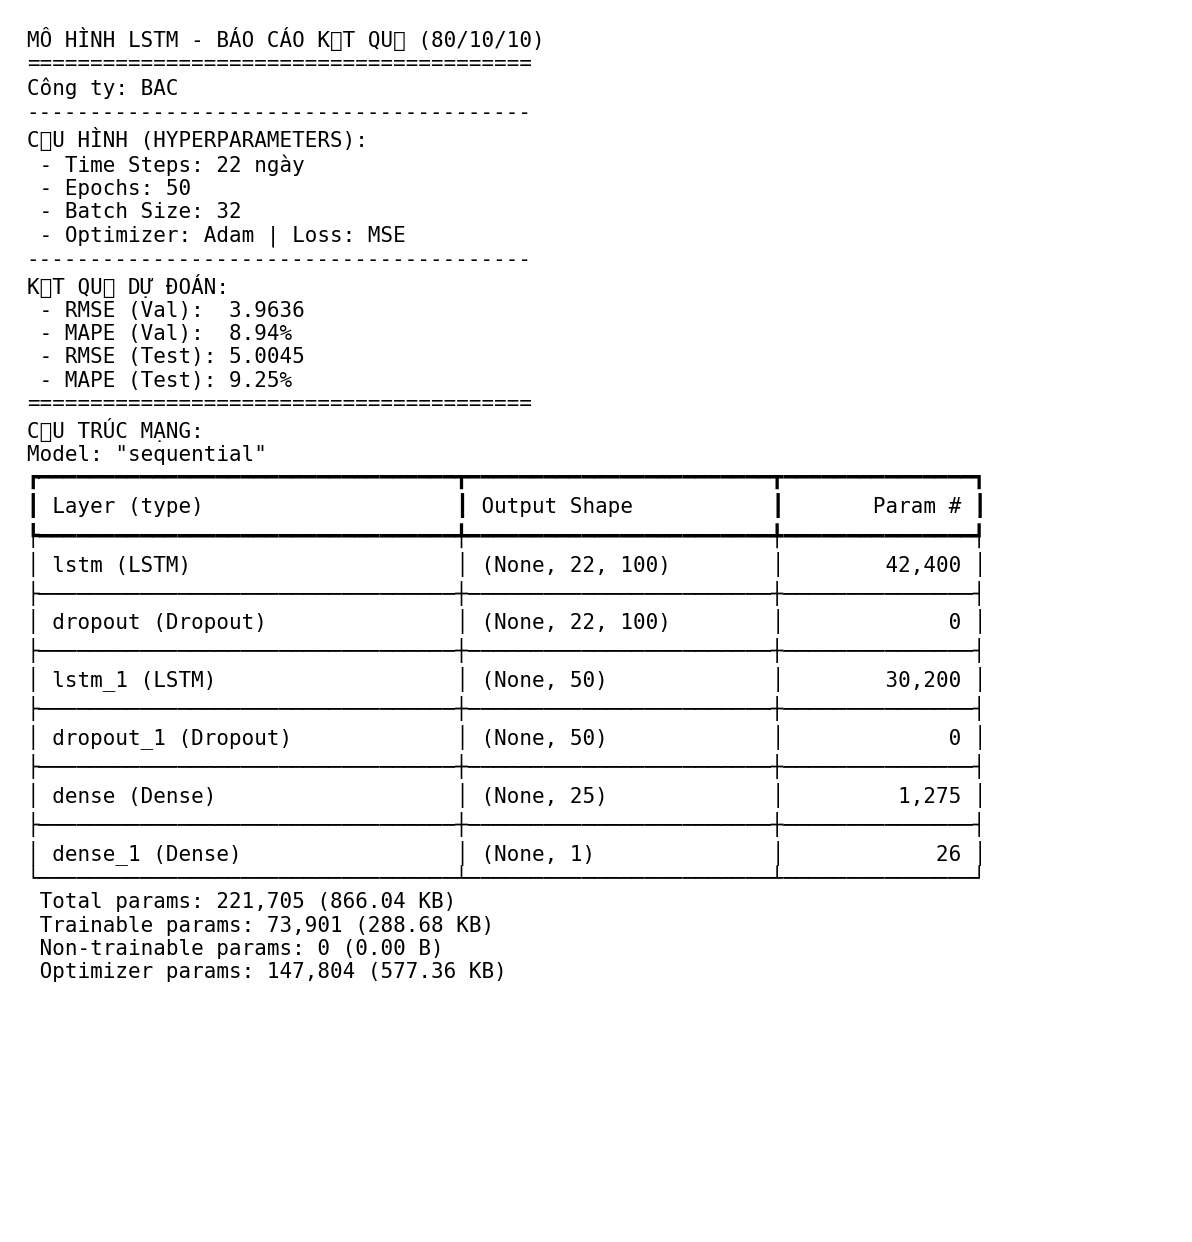

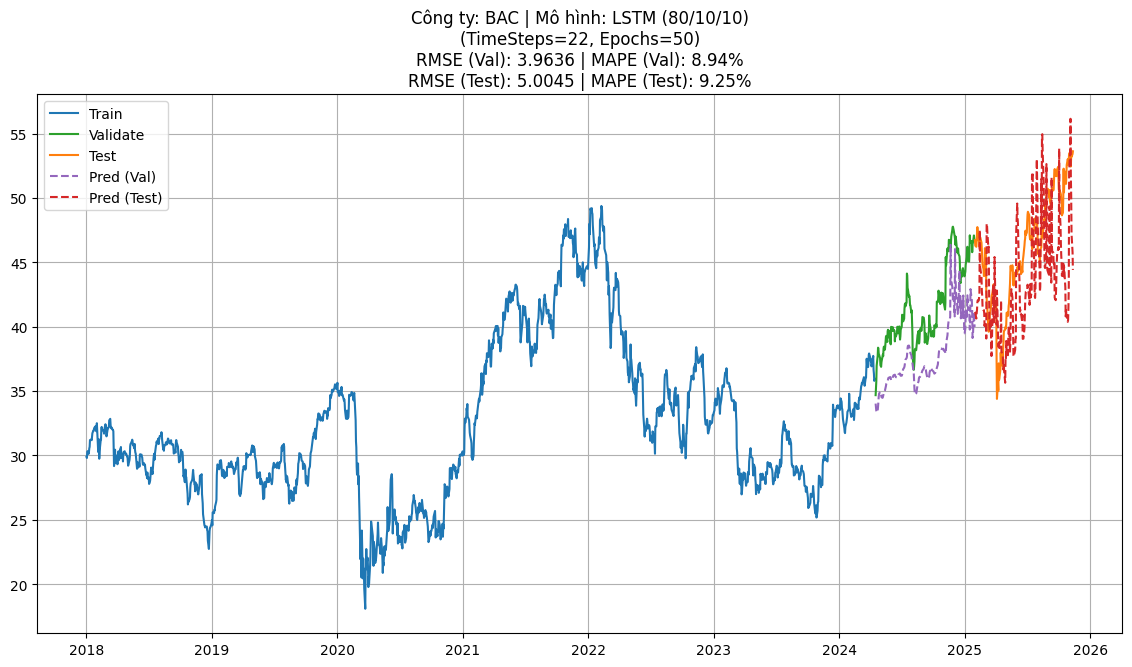


ĐANG XỬ LÝ: JPM.csv (LSTM - 80/10/10)
   > Tìm thấy cột ngày: 'Date'. Đang chuẩn hóa...
   > Biến ngoại sinh: ['SPX500_Close', 'EFFR', 'JPM_news_count', 'JPM_avg_sentiment']
   > Train: 1581, Val: 198, Test: 198
   > Đang chuẩn hóa dữ liệu (Scaling)...
   > Tạo cửa sổ (TimeSteps=22)...
   > Xây dựng & Huấn luyện mô hình...
   > Đang dự đoán Rolling...
   ✓ Xong. RMSE(Test): 41.4183 | MAPE(Test): 10.82% | Time: 46.0s
Đang tạo ảnh báo cáo cho JPM...


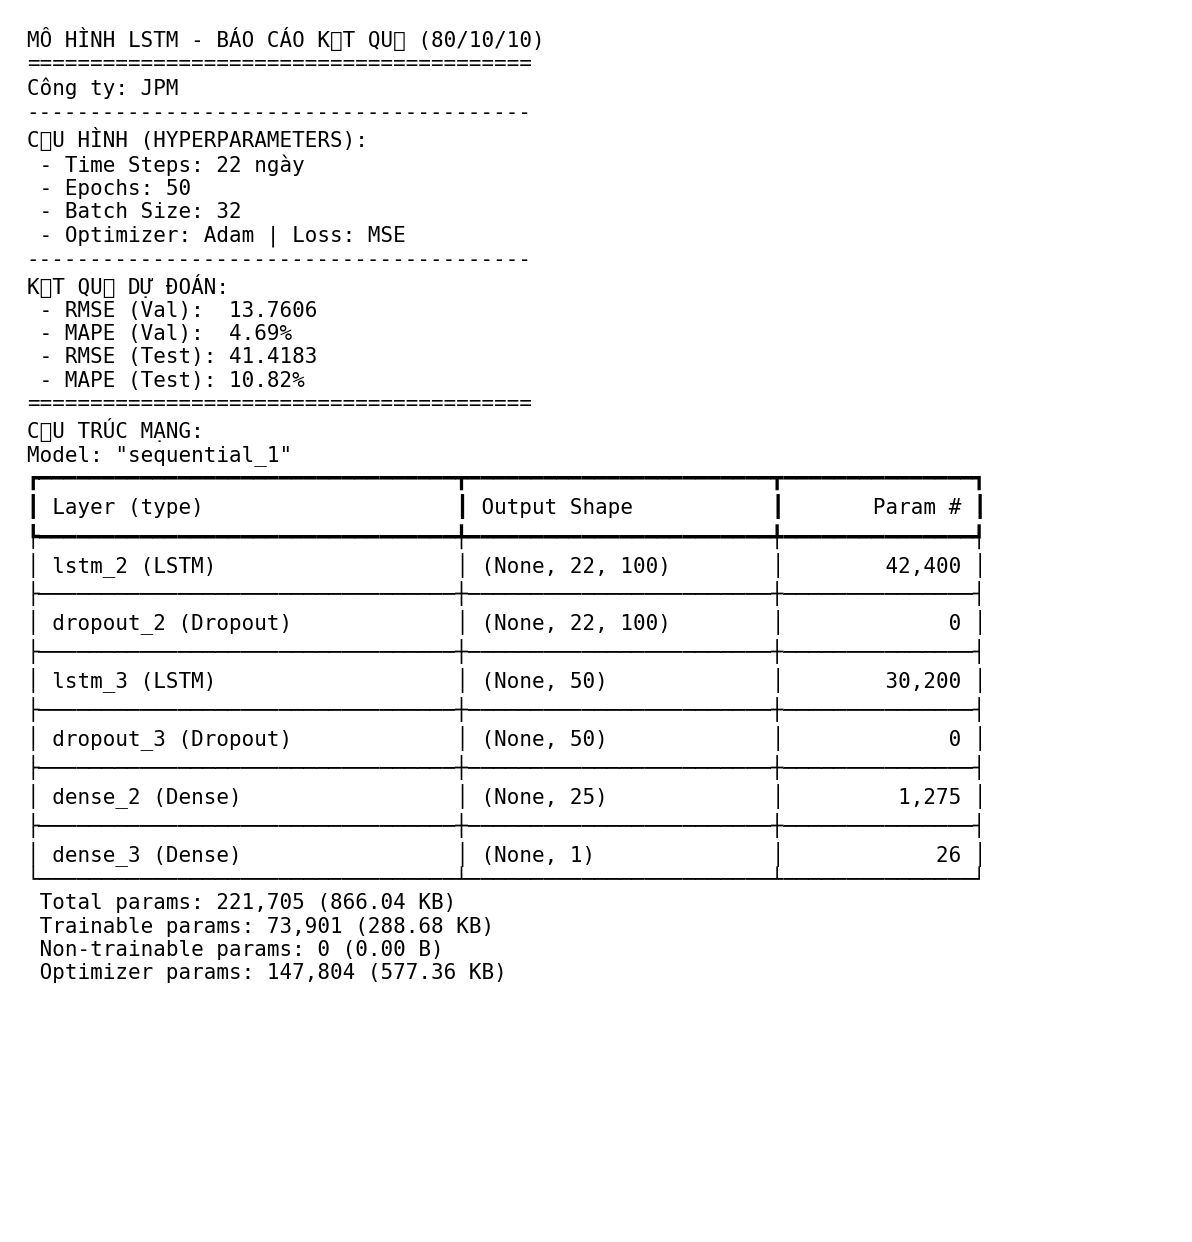

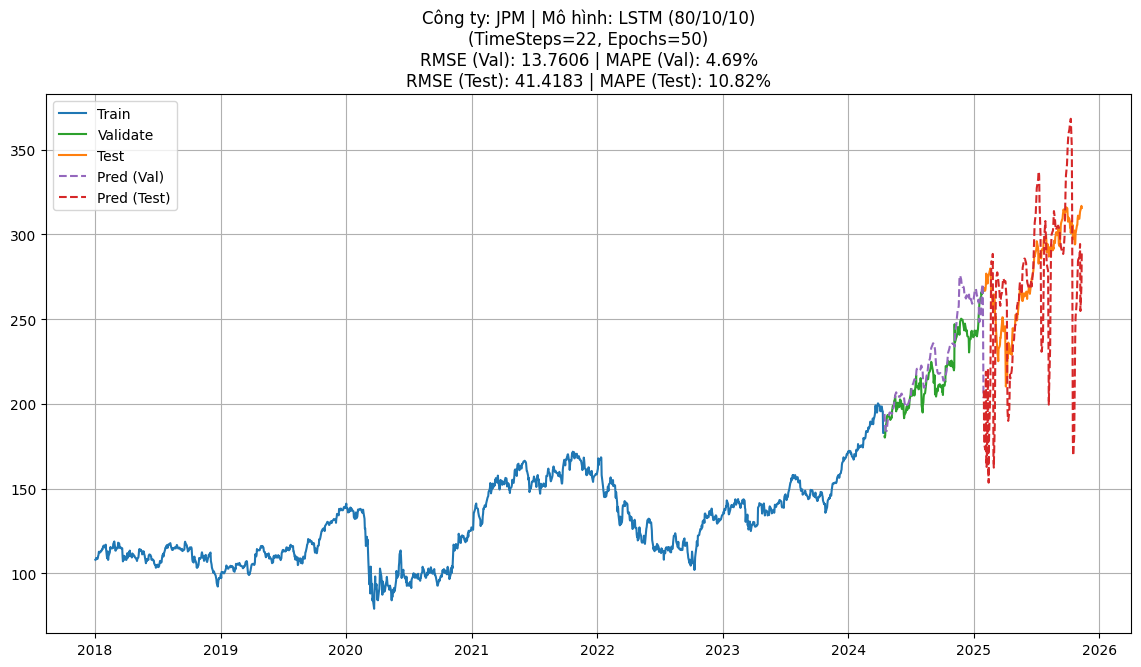


ĐANG XỬ LÝ: WFC.csv (LSTM - 80/10/10)
   > Tìm thấy cột ngày: 'Date'. Đang chuẩn hóa...
   > Biến ngoại sinh: ['SPX500_Close', 'EFFR', 'WFC_news_count', 'WFC_avg_sentiment']
   > Train: 1579, Val: 197, Test: 198
   > Đang chuẩn hóa dữ liệu (Scaling)...
   > Tạo cửa sổ (TimeSteps=22)...
   > Xây dựng & Huấn luyện mô hình...
   > Đang dự đoán Rolling...
   ✓ Xong. RMSE(Test): 23.2025 | MAPE(Test): 26.61% | Time: 48.9s
Đang tạo ảnh báo cáo cho WFC...


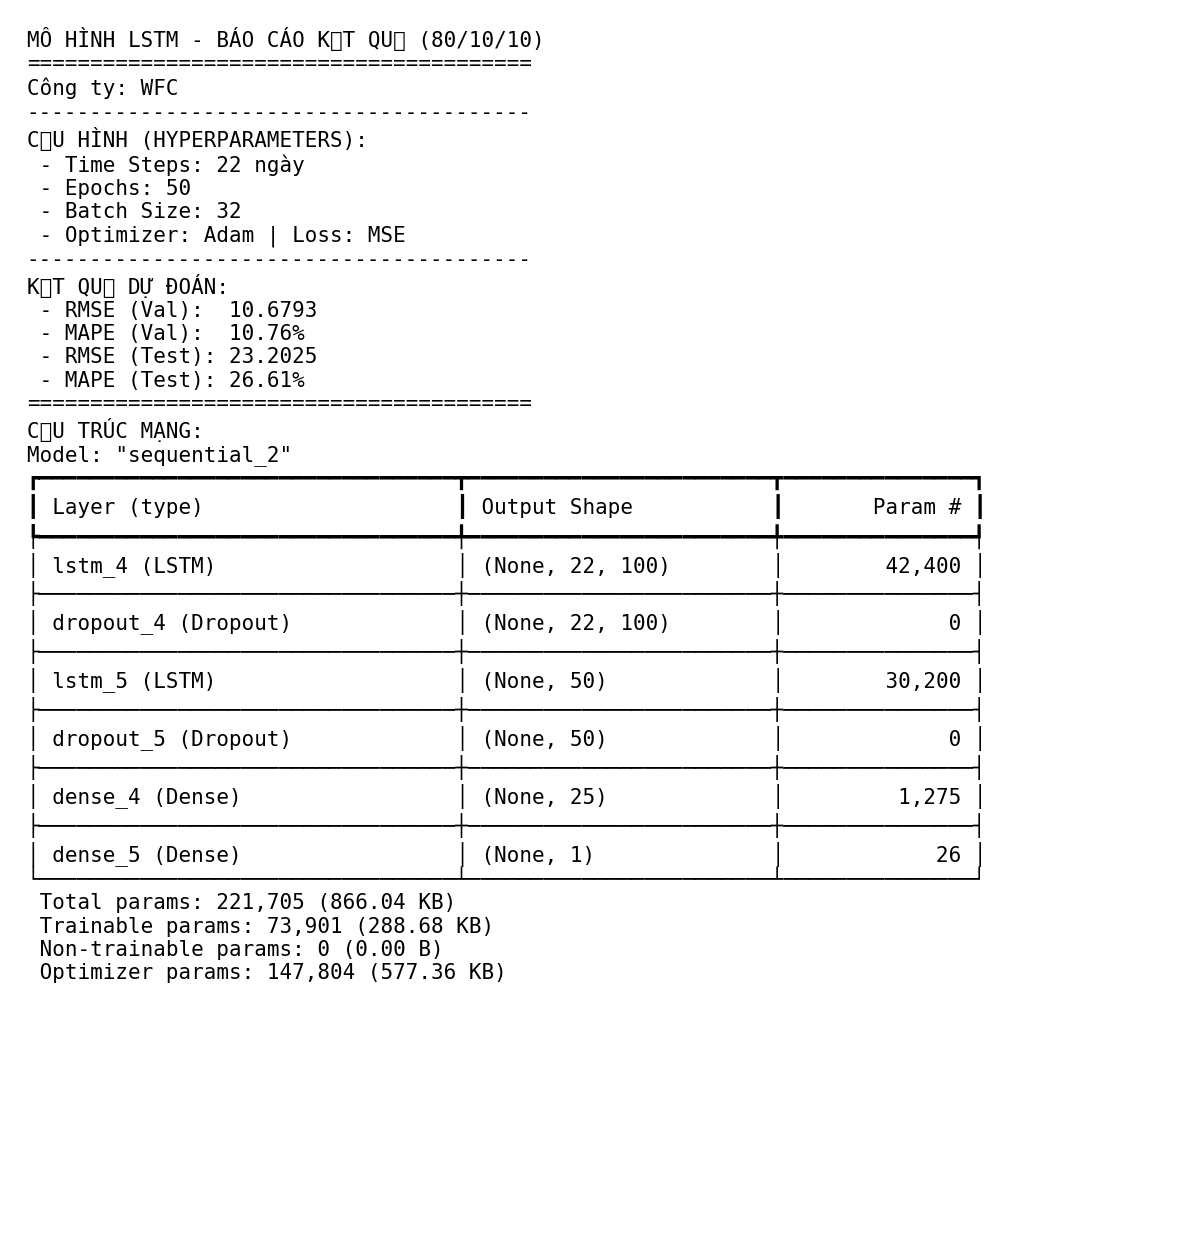

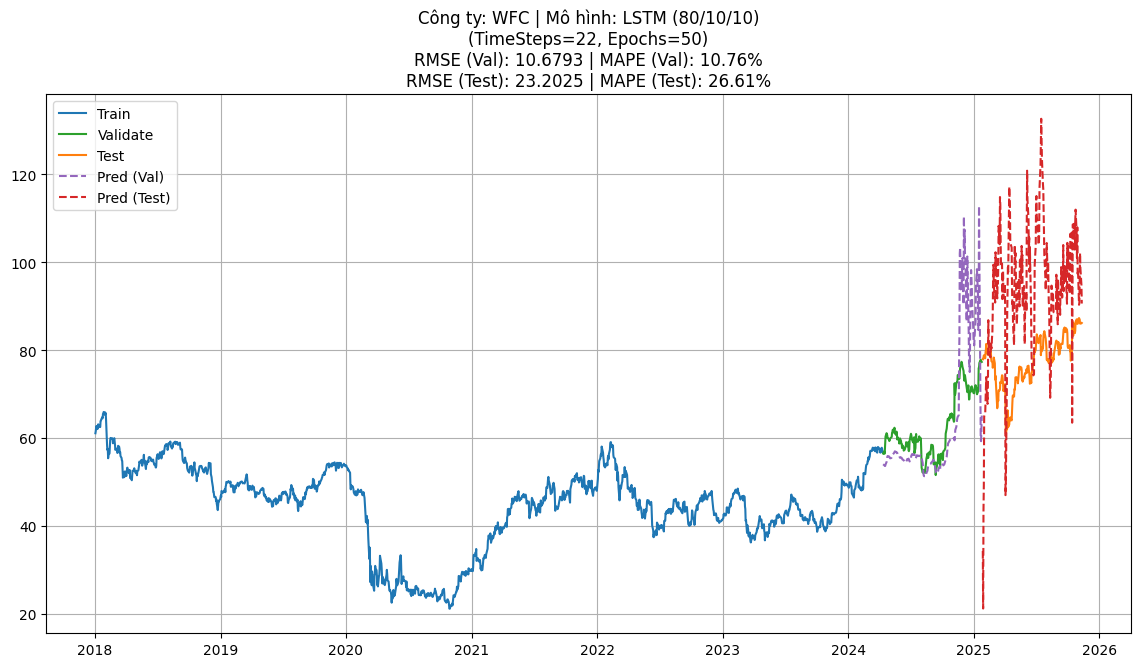


BẢNG TỔNG HỢP KẾT QUẢ (LSTM - 80/10/10)
  Company   RMSE_Val MAPE_Val  RMSE_Test MAPE_Test   Time_Sec
0     BAC   3.963622    8.94%   5.004486     9.25%  45.992127
1     JPM  13.760571    4.69%  41.418328    10.82%  45.975587
2     WFC  10.679267   10.76%  23.202497    26.61%  48.935663


In [ ]:
# @title
# ===========================
# 1. IMPORTS & CÀI ĐẶT MÔI TRƯỜNG
# ===========================
import os
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"
import warnings
warnings.filterwarnings("ignore")

import io, gc, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from math import sqrt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import textwrap
from PIL import Image, ImageDraw, ImageFont

# --- CẤU HÌNH LSTM ---
TIME_STEPS = 22
EPOCHS = 50
BATCH_SIZE = 32
# ---------------------

def normalize_date_index(df):
    date_col = None
    if 'Date' in df.columns: date_col = 'Date'
    elif 'date' in df.columns: date_col = 'date'
    elif 'observation_date' in df.columns: date_col = 'observation_date'
    elif df.index.name and 'date' in df.index.name.lower():
        df.index = pd.to_datetime(df.index).normalize()
        if not df.index.is_unique:
            df = df[~df.index.duplicated(keep='first')]
        return df
    if date_col:
        print(f"   > Tìm thấy cột ngày: '{date_col}'. Đang chuẩn hóa...")
        df[date_col] = pd.to_datetime(df[date_col]).dt.normalize()
        df = df.set_index(date_col)
        if not df.index.is_unique:
            df = df[~df.index.duplicated(keep='first')]
        return df
    else:
        raise ValueError("Không tìm thấy cột ngày hợp lệ.")

def create_windowed_dataset(X_data, y_data, time_steps=TIME_STEPS):
    X, y = [], []
    for i in range(len(X_data) - time_steps):
        window = X_data[i:(i + time_steps)]
        target = y_data[i + time_steps]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

def plot_lstm_report(model, company_name, rmse_val, mape_val, rmse_test, mape_test, time_steps, epochs, batch_size):
    print(f"Đang tạo ảnh báo cáo cho {company_name}...")
    stringlist = []
    model.summary(print_fn=lambda x: stringlist.append(x))
    model_summary = "\n".join(stringlist)

    report_text = (
        f"MÔ HÌNH LSTM - BÁO CÁO KẾT QUẢ (80/10/10)\n"
        f"========================================\n"
        f"Công ty: {company_name}\n"
        f"----------------------------------------\n"
        f"CẤU HÌNH (HYPERPARAMETERS):\n"
        f" - Time Steps: {time_steps} ngày\n"
        f" - Epochs: {epochs}\n"
        f" - Batch Size: {batch_size}\n"
        f" - Optimizer: Adam | Loss: MSE\n"
        f"----------------------------------------\n"
        f"KẾT QUẢ DỰ ĐOÁN:\n"
        f" - RMSE (Val):  {rmse_val:.4f}\n"
        f" - MAPE (Val):  {mape_val*100:.2f}%\n"
        f" - RMSE (Test): {rmse_test:.4f}\n"
        f" - MAPE (Test): {mape_test*100:.2f}%\n"
        f"========================================\n"
        f"CẤU TRÚC MẠNG:\n"
        f"{model_summary}"
    )
    num_lines = len(report_text.split('\n'))
    h_img = max(10, num_lines * 0.25 + 1)
    fig = plt.figure(figsize=(10, h_img))
    ax = fig.add_subplot(111); ax.axis('off')
    ax.text(0.01, 0.99, report_text, va='top', family='monospace', fontsize=10, transform=ax.transAxes)
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', dpi=150)
    plt.close(fig)
    img = Image.open(buf)
    fname = f"report_LSTM_80_10_10_{company_name}.png"
    img.save(fname)
    display(img)
    buf.close()

# ===========================
# BƯỚC 1: UPLOAD
# ===========================
print("--- BƯỚC 1: UPLOAD FILE ---")
print("1. Upload file Ngân hàng:")
uploaded_banks = files.upload()
if not uploaded_banks: raise SystemExit("Thiếu file ngân hàng.")
print("2. Upload file S&P 500:")
uploaded_spx = files.upload()
if not uploaded_spx: raise SystemExit("Thiếu file SPX500.")
print("3. Upload file FED:")
uploaded_fed = files.upload()
if not uploaded_fed: raise SystemExit("Thiếu file FED.")
print("4. Upload file Sentiment:")
uploaded_sentiment = files.upload()
if not uploaded_sentiment: raise SystemExit("Thiếu file Sentiment.")

# ===========================
# BƯỚC 2: XỬ LÝ X
# ===========================
try:
    spx_fn = next(iter(uploaded_spx))
    df_spx = pd.read_csv(io.BytesIO(uploaded_spx[spx_fn]))
    df_spx = normalize_date_index(df_spx)
    spx_col = 'Close' if 'Close' in df_spx.columns else df_spx.columns[0]
    df_spx = df_spx[[spx_col]].rename(columns={spx_col: 'SPX500_Close'})
    df_spx['SPX500_Close'] = pd.to_numeric(df_spx['SPX500_Close'], errors='coerce')

    fed_fn = next(iter(uploaded_fed))
    df_fed = pd.read_csv(io.BytesIO(uploaded_fed[fed_fn]))
    df_fed = normalize_date_index(df_fed)
    fed_col = 'EFFR' if 'EFFR' in df_fed.columns else df_fed.columns[0]
    df_fed = df_fed[[fed_col]].rename(columns={fed_col: 'EFFR'})
    df_fed['EFFR'] = pd.to_numeric(df_fed['EFFR'], errors='coerce')

    sent_fn = next(iter(uploaded_sentiment))
    df_sent = pd.read_csv(io.BytesIO(uploaded_sentiment[sent_fn]))
    df_sent = normalize_date_index(df_sent)
    for col in df_sent.columns:
        df_sent[col] = pd.to_numeric(df_sent[col], errors='coerce')

    exog_master_df = pd.concat([df_spx, df_fed, df_sent], axis=1, join='outer')
    exog_master_df['EFFR'] = exog_master_df['EFFR'].ffill()
    exog_master_df['SPX500_Close'] = exog_master_df['SPX500_Close'].ffill()
    exog_master_df = exog_master_df.fillna(0)
    print("\nXử lý xong dữ liệu ngoại sinh.")
except Exception as e:
    raise SystemExit(f"Lỗi xử lý file ngoại sinh: {e}")

# ===========================
# BƯỚC 3: MAIN LOOP (80/10/10)
# ===========================
series_name = 'Close'
master_summary_list = []

for file_name, file_content in uploaded_banks.items():
    print("\n" + "="*80)
    print(f"ĐANG XỬ LÝ: {file_name} (LSTM - 80/10/10)")
    company_name = os.path.splitext(file_name)[0]

    try:
        y_df = pd.read_csv(io.BytesIO(file_content))
        y_df = normalize_date_index(y_df)
        y_df[series_name] = pd.to_numeric(y_df[series_name], errors='coerce')
        df_full = y_df.join(exog_master_df, how='left')

        global_exog = ['SPX500_Close', 'EFFR']
        company_prefix = company_name.split(" ")[0].split("(")[0]
        bank_exog = [col for col in df_full.columns if col.startswith(company_prefix) and col not in [series_name]]
        final_exog_cols = global_exog + bank_exog
        print(f"   > Biến ngoại sinh: {final_exog_cols}")

        df_full = df_full.dropna(subset=[series_name])
        df_full[final_exog_cols] = df_full[final_exog_cols].ffill().bfill()

        all_feature_cols = [series_name] + final_exog_cols
        y_series = df_full[series_name].values.reshape(-1, 1)
        X_df = df_full[all_feature_cols]

        # --- CHIA 80/10/10 ---
        n = len(df_full)
        split1, split2 = int(n*0.8), int(n*0.9)

        X_train_df = X_df.iloc[:split1]
        X_val_df = X_df.iloc[split1:split2]
        X_test_df = X_df.iloc[split2:]

        y_train_series = y_series[:split1]
        y_val_series = y_series[split1:split2]
        y_test_series = y_series[split2:]

        print(f"   > Train: {len(X_train_df)}, Val: {len(X_val_df)}, Test: {len(X_test_df)}")

        print("   > Đang chuẩn hóa dữ liệu (Scaling)...")
        scaler_y = MinMaxScaler(feature_range=(0, 1))
        y_train_scaled = scaler_y.fit_transform(y_train_series)

        scaler_x = MinMaxScaler(feature_range=(0, 1))
        X_train_scaled = scaler_x.fit_transform(X_train_df)
        X_val_scaled = scaler_x.transform(X_val_df)
        X_test_scaled = scaler_x.transform(X_test_df)

        print(f"   > Tạo cửa sổ (TimeSteps={TIME_STEPS})...")
        X_train_window, y_train_window = create_windowed_dataset(
            X_train_scaled, y_train_scaled.flatten(), TIME_STEPS
        )

    except Exception as e:
        print(f"Lỗi chuẩn bị dữ liệu: {e}. Bỏ qua.")
        continue

    try:
        t0 = time.time()
        print("   > Xây dựng & Huấn luyện mô hình...")
        model = Sequential()
        model.add(LSTM(100, return_sequences=True, input_shape=(X_train_window.shape[1], X_train_window.shape[2])))
        model.add(Dropout(0.2))
        model.add(LSTM(50, return_sequences=False))
        model.add(Dropout(0.2))
        model.add(Dense(25))
        model.add(Dense(1))
        model.compile(optimizer='adam', loss='mean_squared_error')

        early_stop = EarlyStopping(monitor='loss', patience=10, verbose=0)
        model.fit(X_train_window, y_train_window, epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stop], verbose=0, shuffle=False)

        print("   > Đang dự đoán Rolling...")
        def predict_rolling(model, history_scaled, new_data_scaled, scaler_y, time_steps):
            preds = []
            history = list(history_scaled)
            for i in range(len(new_data_scaled)):
                input_window = np.array(history[-time_steps:]).reshape(1, time_steps, -1)
                pred_scaled = model.predict(input_window, verbose=0)
                pred_val = scaler_y.inverse_transform(pred_scaled)[0][0]
                preds.append(pred_val)
                history.append(new_data_scaled[i])
            return preds

        predictions_val_list = predict_rolling(model, X_train_scaled, X_val_scaled, scaler_y, TIME_STEPS)
        full_train_val_scaled = np.concatenate((X_train_scaled, X_val_scaled))
        predictions_test_list = predict_rolling(model, full_train_val_scaled, X_test_scaled, scaler_y, TIME_STEPS)

        preds_val = pd.Series(predictions_val_list, index=X_val_df.index, name='Predictions_Val')
        preds_test = pd.Series(predictions_test_list, index=X_test_df.index, name='Predictions')

        rmse_val = sqrt(mean_squared_error(y_val_series, preds_val))
        rmse_test = sqrt(mean_squared_error(y_test_series, preds_test))
        mape_val = mean_absolute_percentage_error(y_val_series, preds_val)
        mape_test = mean_absolute_percentage_error(y_test_series, preds_test)

        elapsed = time.time() - t0
        print(f"   ✓ Xong. RMSE(Test): {rmse_test:.4f} | MAPE(Test): {mape_test*100:.2f}% | Time: {elapsed:.1f}s")

        plot_lstm_report(model, company_name, rmse_val, mape_val, rmse_test, mape_test, TIME_STEPS, EPOCHS, BATCH_SIZE)

        plt.close('all')
        plt.figure(figsize=(14,7))
        plt.plot(X_train_df.index, y_train_series, label='Train', color='#1f77b4')
        plt.plot(X_val_df.index, y_val_series, label='Validate', color='#2ca02c')
        plt.plot(X_test_df.index, y_test_series, label='Test', color='#ff7f0e')
        plt.plot(preds_val, label='Pred (Val)', color='#9467bd', linestyle='--')
        plt.plot(preds_test, label='Pred (Test)', color='#d62728', linestyle='--')

        title = (
            f"Công ty: {company_name} | Mô hình: LSTM (80/10/10)\n"
            f"(TimeSteps={TIME_STEPS}, Epochs={EPOCHS})\n"
            f"RMSE (Val): {rmse_val:.4f} | MAPE (Val): {mape_val*100:.2f}%\n"
            f"RMSE (Test): {rmse_test:.4f} | MAPE (Test): {mape_test*100:.2f}%"
        )
        plt.title(title); plt.legend(); plt.grid(True); plt.show()

        master_summary_list.append({
            'Company': company_name,
            'RMSE_Val': rmse_val, 'MAPE_Val': f"{mape_val*100:.2f}%",
            'RMSE_Test': rmse_test, 'MAPE_Test': f"{mape_test*100:.2f}%",
            'Time_Sec': elapsed
        })

    except Exception as e:
        print(f"   ✗ Lỗi LSTM: {e}")

if master_summary_list:
    print("\n" + "="*80)
    print("BẢNG TỔNG HỢP KẾT QUẢ (LSTM - 80/10/10)")
    print("="*80)
    df_sum = pd.DataFrame(master_summary_list)
    print(df_sum.to_string())
else:
    print("\nKhông có kết quả nào được tạo.")